# Student-t HDR versus a conformal transported ball

For $Y\sim t_\nu(0,\Sigma)$ in dimension $d$, the $(1-\alpha)$ highest-density region is

$$\{y:y^\top\Sigma^{-1}y\le r^2\},\qquad r^2=dF^{-1}_{d,\nu}(1-\alpha),$$

with log-volume

$$\log V_{\mathrm{HDR}}=\frac d2\log\pi-\log\Gamma(d/2+1)+d\log r+\frac12\log\det\Sigma. $$

The conformal region uses the fitted calibration radius $\hat\rho$, not the population standard-Gaussian radius $\rho^2=\chi^2_d{}^{-1}(1-\alpha)$. For a learned map $T$, its volume is estimated by

$$\log V_{\mathrm{conf}}=\log\operatorname{Vol}(B_{\hat\rho})+\log\mathbb E_{U\sim\operatorname{Unif}(B_{\hat\rho})}[|\det J_T(U)|].$$

The reported metric is the normalized log-volume fraction $\operatorname{NVF}=(\log V_{\mathrm{conf}}-\log V_{\mathrm{HDR}})/d$. The fast path reads it from every new `metrics.json`; for legacy files it reconstructs the same log-domain quantity from the standard conformal `log_volume_per_dimension` metric. The final cell can recompute one selected checkpoint through `compute_student_t_volume_comparison`, which calls the fitted conformal predictor's `estimate_log_volume` implementation.

> **Scale convention.** Both this benchmark and `notebooks/illustrating_the_theorem/generative_distributions.ipynb` use $\Sigma=\operatorname{diag}(k^{1-1/d},k^{-1/d},\ldots,k^{-1/d})$, so $\det\Sigma=1$ and the optimal HDR volume is independent of $k$. Neural OT coordinate-wise target standardization is disabled for this suite so that it does not whiten away the $k$-dependent anisotropy. Thus the $k$ sweep isolates the learned transport's response to conditioning.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch


def find_repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd())
RESULTS_ROOT = REPOSITORY_ROOT / "benchmark/results/student_t"
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))
sns.set_theme(style="whitegrid", context="notebook")

print(f"Repository: {REPOSITORY_ROOT}")
print(f"Results:    {RESULTS_ROOT}")

Repository: <repository-root>
Results:    benchmark/results/student_t


## Parameters

Use `STAGES = ["base"]` for only the base transport, `STAGES = ["rearranged"]` for only the continuous rearrangement, or keep both for comparison.

In [2]:
STAGES = ["base", "rearranged"]
NU = 3.0
DIMENSIONS = [2, 4, 8, 16, 32]
K_VALUES = [1, 2, 4, 8, 16, 32]

# Optional one-checkpoint recomputation in the last cell.
RECOMPUTE_SELECTED_RUN = False
SELECTED_STAGE = "base"
SELECTED_DIMENSION = 4
SELECTED_K = 2
SELECTED_SEED = 0
MC_SAMPLES = 10_000
MC_BATCH_SIZE = 1_024
MC_SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Load the saved comparisons

The reported quantity is $\operatorname{NVF}=(\log V_{\mathrm{conf}}-\log V_{\mathrm{HDR}})/d$: zero is population-optimal and positive values indicate excess log-volume per dimension. A finite conformal calibration can occasionally produce a negative NVF because its conditional-on-calibration population coverage need not equal the nominal mass exactly. Individual runs use the Monte Carlo sample count shown in the table.

In [3]:
STAGE_TO_FOLDER = {
    "base": "transport_neural_ot_l2",
    "rearranged": "transport_neural_ot_rearranged_l2",
}
if not STAGES:
    raise ValueError("Select at least one stage.")
unknown_stages = set(STAGES) - STAGE_TO_FOLDER.keys()
if unknown_stages:
    raise ValueError(f"Unknown stages: {sorted(unknown_stages)}")

records = []
config_paths = {
    *RESULTS_ROOT.glob("dim_*/k_*/*/seed_*/config.json"),
    *RESULTS_ROOT.glob("nu_*_k_*_y_dim_*/*/seed_*/config.json"),
}
for config_path in sorted(config_paths):
    run_directory = config_path.parent
    folder = run_directory.parent.name
    stage = next((name for name, value in STAGE_TO_FOLDER.items() if value == folder), None)
    if stage not in STAGES:
        continue

    with config_path.open(encoding="utf-8") as file:
        config = json.load(file)
    with (run_directory / "metrics.json").open(encoding="utf-8") as file:
        metrics = json.load(file)
    dataset = config["dataset_config"]
    dimension = dataset["y_dim"]
    if "student_t_normalized_volume_fraction" in metrics:
        comparison = metrics["student_t_normalized_volume_fraction"]
        hdr_log_volume = comparison["student_t_hdr_log_volume"]
        conformal_log_volume = comparison["conformal_region_log_volume"]
        nvf = comparison["normalized_log_volume_fraction"]
        volume_source = "conformal comparison"
    else:
        comparison = metrics["student_t_hdr_volume_ratio"]
        hdr_log_volume = comparison["student_t_hdr_log_volume"]
        conformal_log_volume = (
            dimension * metrics["log_volume_per_dimension"]["mean"]
        )
        nvf = (conformal_log_volume - hdr_log_volume) / dimension
        volume_source = "legacy standard conformal-volume metric"
    records.append({
        "stage": stage,
        "dimension": dimension,
        "k": dataset["k"],
        "nu": dataset["nu"],
        "seed": config["seed"],
        "hdr_log_volume": hdr_log_volume,
        "conformal_log_volume": conformal_log_volume,
        "volume_source": volume_source,
        "normalized_log_volume_fraction": nvf,
        "volume_mc_samples": comparison["volume_mc_samples"],
    })

results = pd.DataFrame(records)
results = results[
    results["dimension"].isin(DIMENSIONS)
    & results["k"].isin(K_VALUES)
    & results["nu"].eq(NU)
].reset_index(drop=True)
if results.empty:
    raise FileNotFoundError("No matching saved Student-t metrics were found.")

summary = (
    results.groupby(["stage", "dimension", "k"], as_index=False)
    .agg(
        mean_nvf=("normalized_log_volume_fraction", "mean"),
        std_nvf=("normalized_log_volume_fraction", "std"),
        runs=("seed", "size"),
        mc_samples=("volume_mc_samples", "first"),
    )
)
display(summary.round(4))

,stage,dimension,k,mean_nvf,std_nvf,runs,mc_samples
0,base,2,2.0,0.0080,0.0520,5,1000
1,base,2,4.0,0.0081,0.0519,5,1000
2,base,2,8.0,0.0080,0.0520,5,1000
3,base,2,16.0,0.0081,0.0519,5,1000
4,base,4,2.0,-0.0019,0.0225,5,1000
5,base,4,4.0,-0.0018,0.0223,5,1000
6,base,4,8.0,-0.0018,0.0223,5,1000
7,base,4,16.0,-0.0018,0.0224,5,1000
8,base,8,2.0,0.0318,0.0596,5,1000
9,base,8,4.0,0.0318,0.0596,5,1000


## Effect of dimension and anisotropy

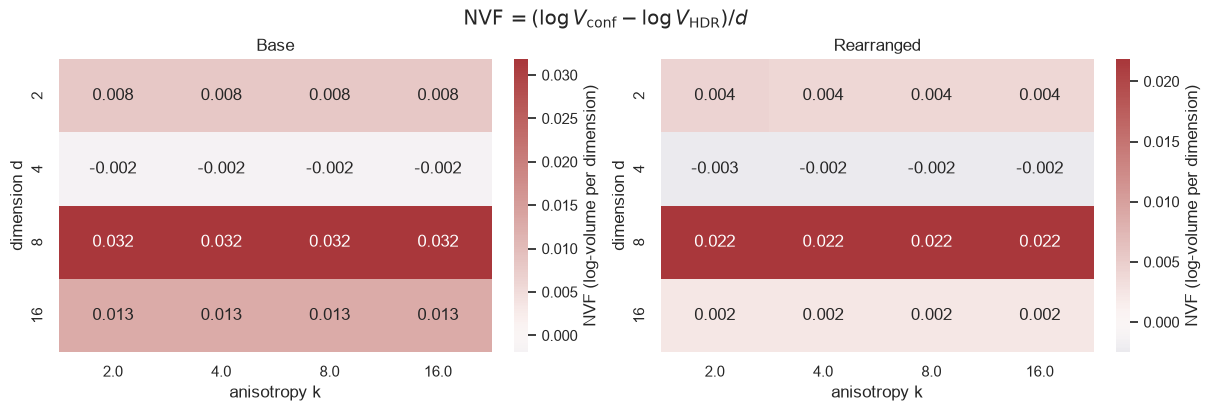

In [4]:
figure, axes = plt.subplots(
    1, len(STAGES), figsize=(6 * len(STAGES), 4), squeeze=False, constrained_layout=True
)
for axis, stage in zip(axes[0], STAGES):
    heatmap = summary[summary["stage"] == stage].pivot(
        index="dimension", columns="k", values="mean_nvf"
    )
    sns.heatmap(
        heatmap, annot=True, fmt=".3f", cmap="vlag", center=0.0,
        cbar_kws={"label": "NVF (log-volume per dimension)"}, ax=axis,
    )
    axis.set_title(stage.capitalize())
    axis.set_xlabel("anisotropy k")
    axis.set_ylabel("dimension d")
figure.suptitle(r"$\operatorname{NVF}=(\log V_{\mathrm{conf}}-\log V_{\mathrm{HDR}})/d$")
plt.show()

## Optional: recompute one checkpoint

Set `RECOMPUTE_SELECTED_RUN = True` above to reload the selected transport and its fitted conformal threshold, then rerun the Jacobian Monte Carlo estimate. This is intentionally limited to one run so the notebook remains quick by default.

In [5]:
if RECOMPUTE_SELECTED_RUN:
    from configs.predictors.transport import NeuralOptimalTransportPredictorConfig
    from conformal import TransportBasedConformalPredictor
    from data.datasets.synthetic import StudentTDataset
    from experimentation import compute_student_t_volume_comparison, load_experiment_config
    from predictors.rearranged_transport import (
        AmortizedRearrangedTransport,
        RearrangedTransportPredictor,
    )
    from predictors.transport import NeuralOptimalTransportPredictor

    run_directory = (
        RESULTS_ROOT / f"dim_{SELECTED_DIMENSION}" / f"k_{SELECTED_K:g}"
        / STAGE_TO_FOLDER[SELECTED_STAGE]
        / f"seed_{SELECTED_SEED:02d}"
    )
    experiment_config = load_experiment_config(run_directory / "config.json")

    if SELECTED_STAGE == "base":
        checkpoint_path = run_directory / "base/predictor.pt"
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        predictor_config = NeuralOptimalTransportPredictorConfig.model_validate(
            {**checkpoint["config"], "device": DEVICE}
        )
        predictor = NeuralOptimalTransportPredictor(predictor_config)
        predictor.load_state_dict(checkpoint["state_dict"])
    else:
        checkpoint_path = run_directory / "rearrangement/predictor.pt"
        rearrangement_classes = {
            "amortized_rearranged_transport": AmortizedRearrangedTransport,
            "rearranged_transport": RearrangedTransportPredictor,
        }
        predictor = rearrangement_classes[
            experiment_config.rearrangement_config.type
        ].load(str(checkpoint_path), map_location=DEVICE)

    predictor.eval()
    conformal_predictor = TransportBasedConformalPredictor(
        predictor=predictor,
        config=experiment_config.conformal_config,
    )
    conformal_checkpoint = torch.load(
        run_directory / "conformal/predictor.pt",
        map_location=DEVICE,
        weights_only=False,
    )
    conformal_predictor.calibrator = conformal_checkpoint["calibrator"]
    dataset_config = experiment_config.dataset_config.model_copy(
        update={"device": DEVICE}
    )
    comparison = compute_student_t_volume_comparison(
        conformal_predictor=conformal_predictor,
        dataset=StudentTDataset(dataset_config),
        number_of_samples=MC_SAMPLES,
        batch_size=MC_BATCH_SIZE,
        seed=MC_SEED,
    )
    display(pd.Series({
        "checkpoint": str(checkpoint_path.relative_to(REPOSITORY_ROOT)),
        "HDR log-volume": comparison["student_t_hdr_log_volume"],
        "conformal log-volume": comparison["conformal_region_log_volume"],
        "NVF": comparison["normalized_log_volume_fraction"],
        "calibrated ball radius": comparison["conformal_ball_radius"],
        "MC samples": comparison["volume_mc_samples"],
    }))
else:
    print("Skipped. Set RECOMPUTE_SELECTED_RUN = True to recompute one checkpoint.")

Skipped. Set RECOMPUTE_SELECTED_RUN = True to recompute one checkpoint.
